In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load House Price Dataset

df = pd.read_csv("dataset/train.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset loaded successfully!
Dataset Shape: (1460, 81)

Column Names:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorch

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Check target variable

print("Target Variable: SalePrice")

print("\nSalePrice Summary:")
display(df["SalePrice"].describe())

print("\nMissing values in SalePrice:")
print(df["SalePrice"].isnull().sum())

Target Variable: SalePrice

SalePrice Summary:


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


Missing values in SalePrice:
0


In [4]:
# Numerical features summary

numeric_summary = df.describe().T

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [5]:
# Missing Values Analysis

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(
    ascending=False
)

print("Columns with Missing Values:")
display(missing_values)

print("\nTotal Missing Values:", df.isnull().sum().sum())

Columns with Missing Values:


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


Total Missing Values: 7829


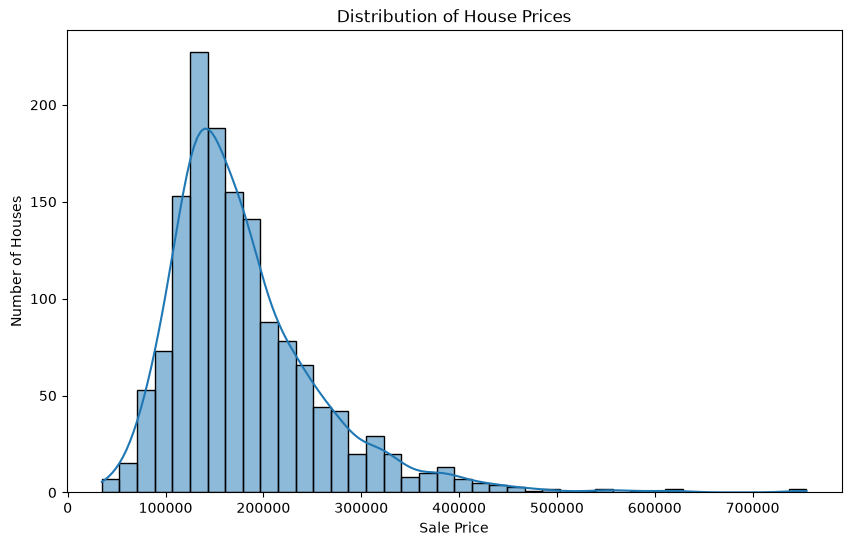

In [6]:
# Distribution of House Prices

plt.figure(figsize=(10, 6))

sns.histplot(
    df["SalePrice"],
    bins=40,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")

plt.show()

In [7]:
# Correlation Analysis

numeric_df = df.select_dtypes(include=np.number)

correlation_with_price = (
    numeric_df.corr()["SalePrice"]
    .sort_values(ascending=False)
)

print("Correlation with SalePrice:")
display(correlation_with_price)

Correlation with SalePrice:


SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

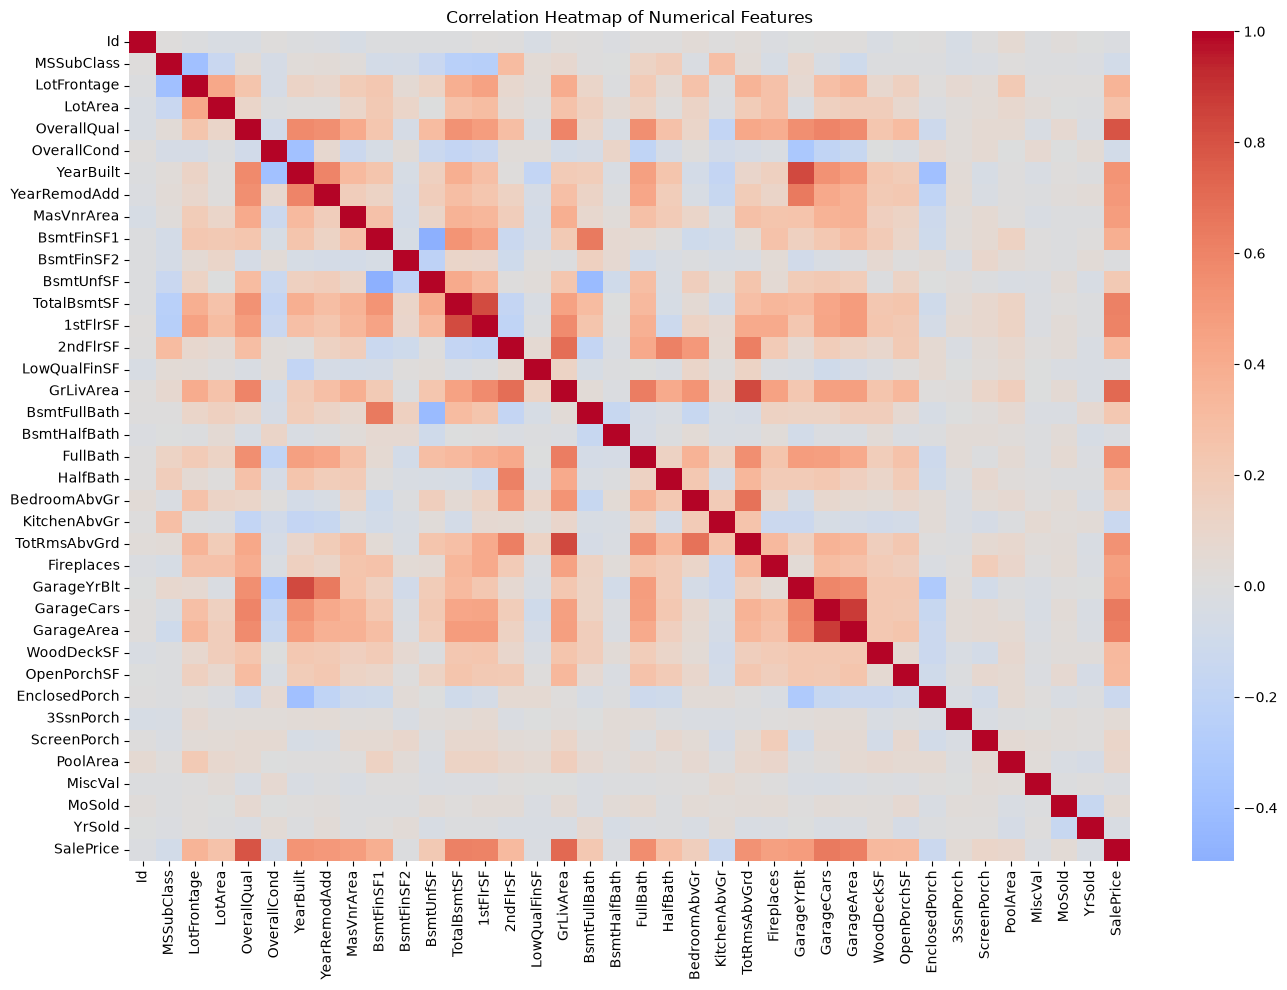

In [8]:
# Correlation Heatmap

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [9]:
# Top features correlated with SalePrice

top_correlations = (
    correlation_with_price
    .drop("SalePrice")
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Features by Absolute Correlation with SalePrice:")
display(top_correlations)

Top 10 Features by Absolute Correlation with SalePrice:


OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

In [10]:
# Handle Missing Values

df_clean = df.copy()

# Numerical columns
numeric_cols = df_clean.select_dtypes(include=np.number).columns

for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical columns
categorical_cols = df_clean.select_dtypes(include="object").columns

for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna("None")

print("Missing values handled successfully!")

print("\nTotal missing values after cleaning:",
      df_clean.isnull().sum().sum())

Missing values handled successfully!

Total missing values after cleaning: 0


In [11]:
# One-Hot Encoding for Categorical Features

X = df_clean.drop("SalePrice", axis=1)
y = df_clean["SalePrice"]

# Convert categorical columns into dummy variables
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

print("One-hot encoding completed!")
print("Encoded Feature Matrix Shape:", X_encoded.shape)

display(X_encoded.head())

One-hot encoding completed!
Encoded Feature Matrix Shape: (1460, 261)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


In [12]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Train-Test Split Completed!")
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Train-Test Split Completed!
Training Features Shape: (1168, 261)
Testing Features Shape: (292, 261)
Training Target Shape: (1168,)
Testing Target Shape: (292,)


In [13]:
# Linear Regression Model

linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Predict house prices on test data
y_pred = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")
print("Number of predictions:", len(y_pred))

Linear Regression model trained successfully!
Number of predictions: 292


In [14]:
# Model Evaluation

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Model Evaluation")
print("-----------------------------------")
print(f"Mean Squared Error (MSE)  : {mse:,.2f}")
print(f"Root Mean Squared Error   : {rmse:,.2f}")
print(f"R² Score                  : {r2:.4f}")

Linear Regression Model Evaluation
-----------------------------------
Mean Squared Error (MSE)  : 1,107,432,517.00
Root Mean Squared Error   : 33,278.11
R² Score                  : 0.8556


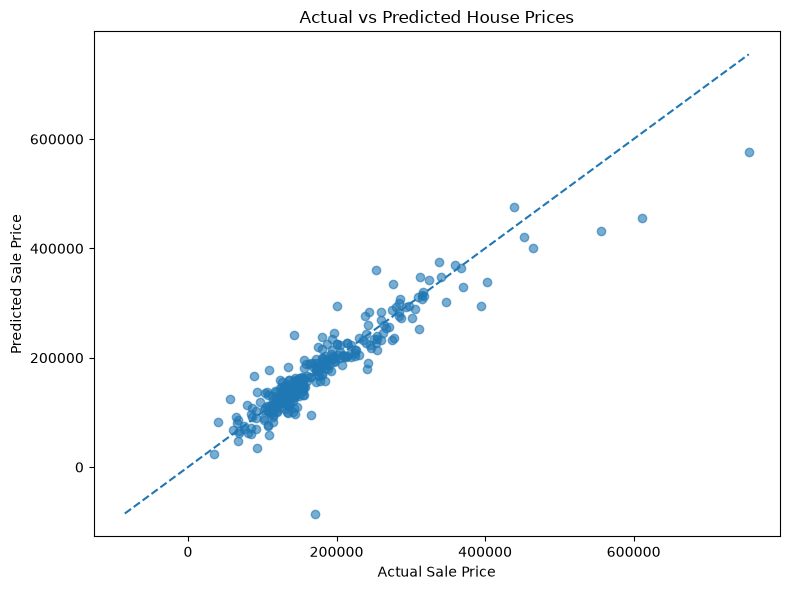

In [15]:
# Actual vs Predicted House Prices

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Perfect prediction reference line
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.tight_layout()
plt.show()

## Conclusion

In this project, a Linear Regression model was developed to predict house sale prices using the Ames Housing dataset.

The dataset was explored through descriptive statistics, missing-value analysis, correlation analysis, and a correlation heatmap. Missing numerical values were handled using median imputation, while missing categorical values were represented as "None".

Categorical features were converted into numerical features using one-hot encoding. The dataset was then divided into 80% training data and 20% testing data.

A Linear Regression model was trained on the processed dataset and evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

The Actual vs Predicted visualization was used to compare the model's predicted prices with the actual sale prices.

Overall, the project demonstrates how exploratory data analysis, data preprocessing, feature encoding, and Linear Regression can be combined to build a house price prediction system.